In [ ]:
import pandas as pd
from datetime import datetime
from IPython.display import display, HTML

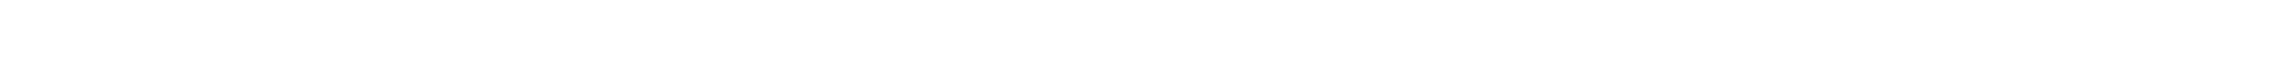

In [ ]:
display(HTML("<style>.container { width:100% !important; }</style>"))

In [ ]:
data = pd.read_csv("../Datasets/siri.20121106.csv", names = ['Timestamp','LineID','Direction','JourneyPatternID','TimeFrame','VehicleJourneyID','Operator','Congestion','Long','Lat','Delay','BlockID ','VehicleID','StopID','AtStop'], dtype = {"LineID": str})

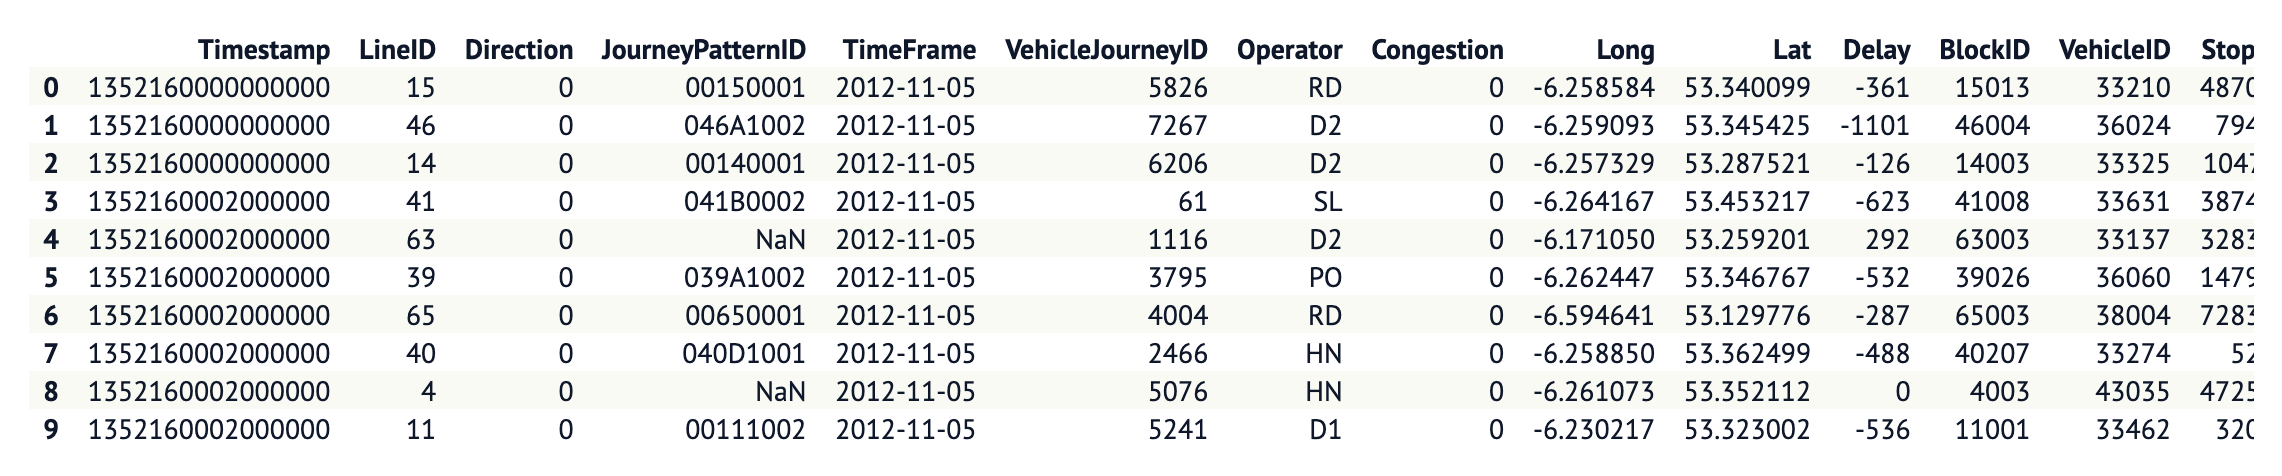

In [ ]:
display(HTML(data.head(10).to_html()))

In [ ]:
vehicles = data.VehicleID.unique()
journeysDF = pd.DataFrame(columns = ['JourneyID','Route', 'StartTime','StartStop', 'Endtime', 'EndStop', 'Duration'])
for v in vehicles:
    pings = data[data.VehicleID == v]
    output = pings[['LineID', 'Direction', 'JourneyPatternID', 'VehicleJourneyID', 'StopID', 'AtStop', 'Timestamp']].copy()
    output['TimeF'] = pings.Timestamp.apply(lambda x: datetime.fromtimestamp(x/1_000_000).strftime('%Y-%m-%d %H:%M:%S'))
    journeys = output.VehicleJourneyID.unique()
    o = pd.DataFrame(columns = ['JourneyID','Route', 'StartTime','StartStop', 'Endtime', 'EndStop', 'Duration'])
    for j in journeys:
        journey = output[output.VehicleJourneyID == j]
        route = journey.iloc[0].LineID
        startTime = journey.iloc[0].TimeF
        startStop = journey.iloc[0].StopID
        endTime = journey.iloc[-1].TimeF
        endStop = journey.iloc[-1].StopID
        x = journey.iloc[-1].Timestamp - journey.iloc[0].Timestamp 
        duration = datetime.fromtimestamp(x/1_000_000).strftime('%H:%M:%S')
        journeysDF = pd.concat([journeysDF, pd.DataFrame({'JourneyID': [j], 'Route': [route], 'StartTime': [startTime], 'StartStop': [startStop], 'Endtime': [endTime], 'EndStop': [endStop], 'Duration': [duration]})], ignore_index = True)

/var/folders/h8/7s7s33b10fsdtf_d12tn7trm0000gn/T/marimo_11481/__marimo__cell_lEQa_.py:18: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  journeysDF = pd.concat([journeysDF, pd.DataFrame({'JourneyID': [j], 'Route': [route], 'StartTime': [startTime], 'StartStop': [startStop], 'Endtime': [endTime], 'EndStop': [endStop], 'Duration': [duration]})], ignore_index = True)


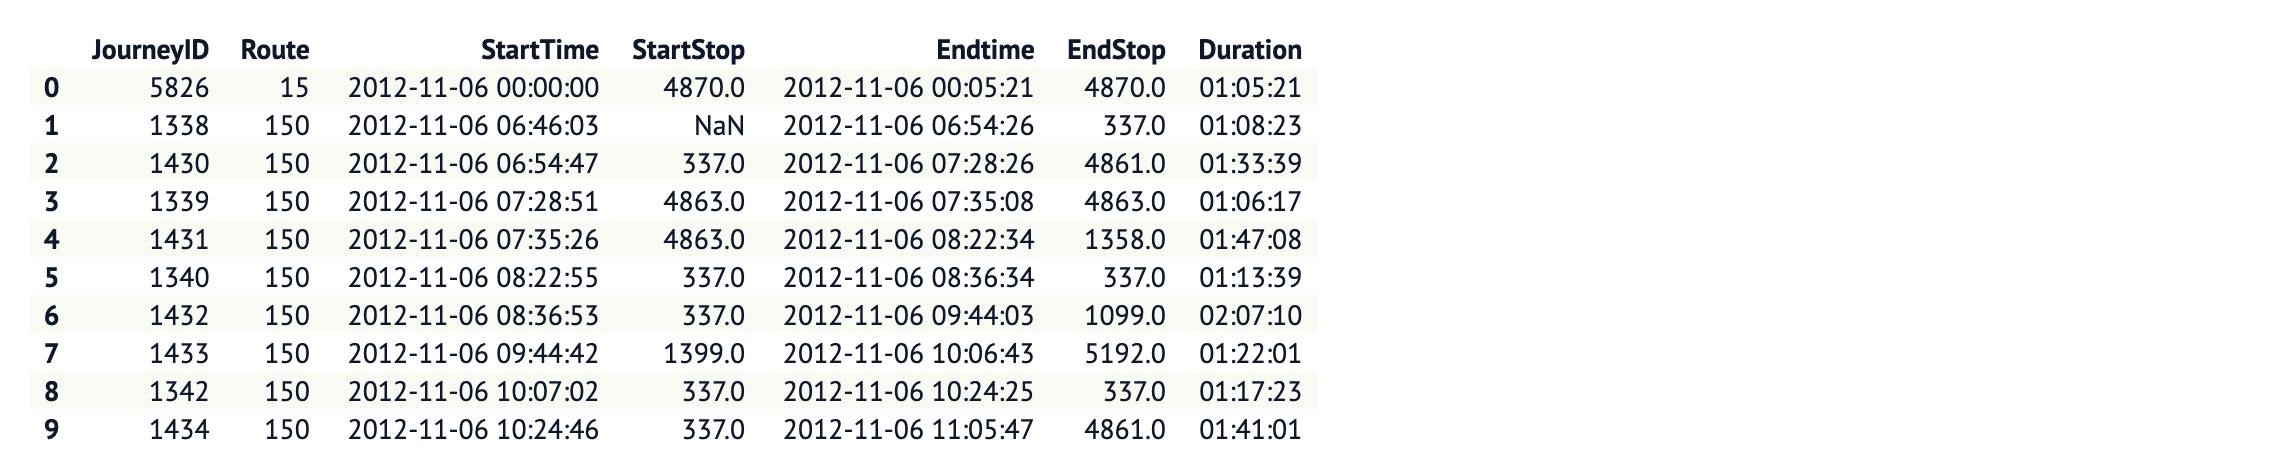

In [ ]:
display(HTML(journeysDF.head(10).to_html()))

In [ ]:
print(journeysDF.shape[0])

13000
